# Model selection: optimal number of states for HMM-GLM

In [1]:
import sys
import os
import pickle
import ssm
import matplotlib.pyplot as plt

# Make sure we're adding the root of Project_monkey
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # Two levels up from notebooks
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now this should work
#from Behaviour.scripts_beh import preprocessing_hmm_glm
from Behaviour.scripts_beh.preprocessing_hmm_glm import *
from Behaviour.scripts_beh.optimal_number_states import *
figures_dir = os.path.join(project_root, "Behaviour", "Figures")
os.makedirs(figures_dir, exist_ok=True)

In [3]:
# From the data select the regressors we would like to include in the inpts, can be modified accordingly
feature_names = [
            'color', 'direction', 'p_color', 'dist_prev_current_color',
            'p_direction', 'dist_prev_current_motion', 'prev_response', 'intercept'
        ]

In [4]:
## Let's Load the data and prepare the inputs for the HMM-GLM
data_path = os.path.join("..", "..", "Data", "sample_data.pkl")
inpts, choices, data = load_and_prepare_glmhmm_inputs(data_path, feature_names)

In [5]:
max_states = 5  # Maximum number of states to search for
n_splits = 2  # Number of splits for cross-validation
initializations = 1  # Number of initializations for each state count
num_iters = 1500  # Number of iterations for the EM algorithm
tolerance = tolerance = 1e-4   # Tolerance for convergence of the EM algorithm


In [6]:
# Running the optimal number of states search
train_LL, test_LL, bits, models = run_state_selection(
    inpts,
    choices, 
    max_states=max_states,
    n_splits=n_splits,
    initializations=initializations,
    num_iters=num_iters,
    tolerance=tolerance)

Fitting HMMs: 100%|████████████████████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.46s/it]


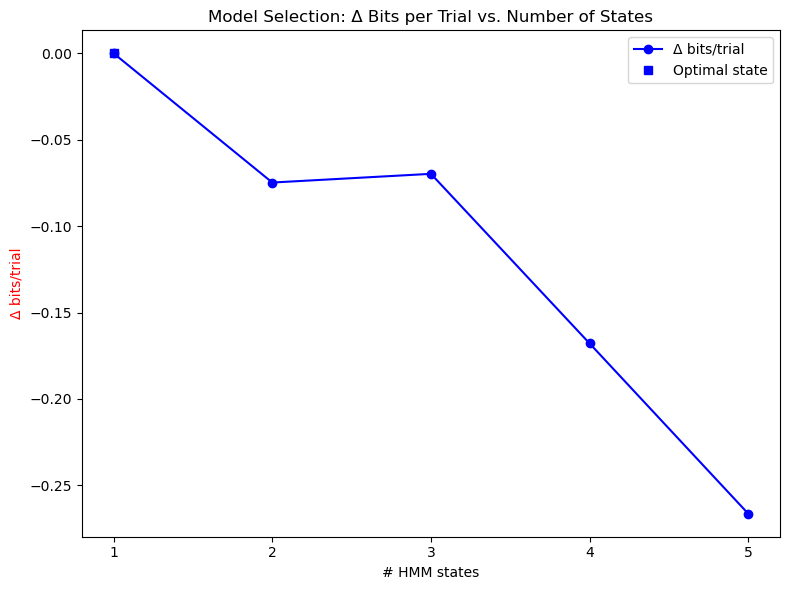

In [9]:
example_bits = bits.mean(axis=-1).max(axis=0)
delta_bits = example_bits - example_bits[0]

max_idx = np.argmax(np.where(delta_bits >= 0, delta_bits, -np.inf))
optimal_states = max_idx + 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(delta_bits, 'b-o', label='Δ bits/trial')
ax.plot(max_idx, delta_bits[max_idx], 'bs', label='Optimal state')

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ bits/trial', color='red')
ax.set_title('Model Selection: Δ Bits per Trial vs. Number of States')
ax.set_xticks(np.arange(len(delta_bits)))
ax.set_xticklabels([str(i + 1) for i in range(len(delta_bits))])
ax.legend()
plt.tight_layout()

# === Save figure ===
fig_path = os.path.join(figures_dir, "model_selection_delta_bits.svg")
plt.savefig(fig_path, format='svg', bbox_inches='tight')

plt.show()
